In [2]:
import os
import glob
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.cuda.amp as amp

# -------------------------------------------------------------
# 1. Hardware & Configuration
# -------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
NUM_CLASSES = 4
EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_WORKERS = 4

print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

# -------------------------------------------------------------
# 2. Dynamic Dataset Discovery & Image Loading
# -------------------------------------------------------------
CLASS_NAMES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
LABEL_MAP = {name: idx for idx, name in enumerate(CLASS_NAMES)}

# Search for the dataset root inside /kaggle/input
possible_roots = []
for root, dirs, _ in os.walk("/kaggle/input"):
    # Detect the directory containing the class folders
    dir_names = set(dirs)
    if "COVID" in dir_names or "Normal" in dir_names:
        possible_roots.append(root)

if not possible_roots:
    raise FileNotFoundError(
        "Could not locate the COVID-19 dataset folders under /kaggle/input. "
        "Please ensure the dataset 'tawsifurrahman/covid19-radiography-database' is attached in the right panel."
    )

BASE_PATH = possible_roots[0]
print(f"Detected dataset root directory at: {BASE_PATH}")

image_paths = []
image_labels = []

# Gather valid CXR images while excluding lung masks
for root, _, files in os.walk(BASE_PATH):
    # Exclude mask directories
    if "mask" in root.lower():
        continue
    
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            full_path = os.path.join(root, file)
            
            # Map image to corresponding class
            for cls_name, cls_idx in LABEL_MAP.items():
                if f"/{cls_name}/" in full_path.replace("\\", "/") or f"/{cls_name.replace(' ', '_')}/" in full_path.replace("\\", "/"):
                    image_paths.append(full_path)
                    image_labels.append(cls_idx)
                    break

print(f"Found {len(image_paths)} total images across {len(CLASS_NAMES)} classes.")

# Print class distribution
for cls_name, cls_idx in LABEL_MAP.items():
    count = image_labels.count(cls_idx)
    print(f"  - {cls_name}: {count} images")

# -------------------------------------------------------------
# 3. Stratified Train / Validation Split (80/20)
# -------------------------------------------------------------
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.20,
    random_state=42,
    stratify=image_labels
)

# -------------------------------------------------------------
# 4. PyTorch Dataset & Transforms
# -------------------------------------------------------------
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class CXRDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # Convert single-channel grayscale X-ray to 3-channel RGB for ResNet
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

train_dataset = CXRDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = CXRDataset(val_paths, val_labels, transform=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# -------------------------------------------------------------
# 5. Model Architecture (ResNet-18 + 4-Class Head)
# -------------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace final Linear layer for 4 disease categories
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)

# Enable DataParallel if Kaggle T4 x2 dual-GPU accelerator is active
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs with DataParallel.")
    model = nn.DataParallel(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
scaler = amp.GradScaler()

# -------------------------------------------------------------
# 6. Training & Validation Execution Loop
# -------------------------------------------------------------
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    # --- Training Phase ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]")
    for images, labels in train_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        train_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = (correct_train / total_train) * 100.0

    # --- Validation Phase ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            with amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (correct_val / total_val) * 100.0

    print(f"\nEpoch {epoch:02d} Summary:")
    print(f"  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"  Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {epoch_val_acc:.2f}%\n")

    # --- Save Best Model Checkpoint ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        save_state = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
        torch.save(save_state, "best_covid_resnet18.pth")
        print(f"New best validation accuracy: {best_val_acc:.2f}%. Checkpoint saved to 'best_covid_resnet18.pth'.\n")

print(f"Training Complete! Best Validation Accuracy: {best_val_acc:.2f}%")

Using device: cuda
Device Name: Tesla T4
Detected dataset root directory at: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset
Found 21165 total images across 4 classes.
  - COVID: 3616 images
  - Lung_Opacity: 6012 images
  - Normal: 10192 images
  - Viral Pneumonia: 1345 images
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s] 
/tmp/ipykernel_58/1746844270.py:162: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


Using 2 GPUs with DataParallel.


Epoch 1/10 [Train]:   0%|          | 0/265 [00:00<?, ?it/s]/tmp/ipykernel_58/1746844270.py:179: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
Epoch 1/10 [Train]: 100%|██████████| 265/265 [01:14<00:00,  3.56it/s, loss=0.2799]
/tmp/ipykernel_58/1746844270.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():



Epoch 01 Summary:
  Train Loss: 0.3199 | Train Acc: 88.19%
  Val   Loss: 0.1921 | Val   Acc: 93.62%

[*] New best validation accuracy: 93.62%. Checkpoint saved to 'best_covid_resnet18.pth'.



...


Epoch 08 Summary:
  Train Loss: 0.0805 | Train Acc: 97.20%
  Val   Loss: 0.1647 | Val   Acc: 95.63%

[*] New best validation accuracy: 95.63%. Checkpoint saved to 'best_covid_resnet18.pth'.



Epoch 9/10 [Train]: 100%|██████████| 265/265 [00:50<00:00,  5.26it/s, loss=0.1632]



Epoch 09 Summary:
  Train Loss: 0.0848 | Train Acc: 96.89%
  Val   Loss: 0.1626 | Val   Acc: 94.50%



Epoch 10/10 [Train]: 100%|██████████| 265/265 [00:51<00:00,  5.10it/s, loss=0.0790]



Epoch 10 Summary:
  Train Loss: 0.0690 | Train Acc: 97.58%
  Val   Loss: 0.1467 | Val   Acc: 95.11%

Training Complete! Best Validation Accuracy: 95.63%


             DETAILED CLASSIFICATION REPORT
                 precision    recall  f1-score   support

          COVID     0.9889    0.9820    0.9854       723
   Lung_Opacity     0.9529    0.9086    0.9302      1203
         Normal     0.9430    0.9735    0.9580      2038
Viral Pneumonia     0.9886    0.9703    0.9794       269

       accuracy                         0.9563      4233
      macro avg     0.9683    0.9586    0.9632      4233
   weighted avg     0.9565    0.9563    0.9561      4233

Macro-Averaged One-vs-Rest ROC-AUC: 0.9929


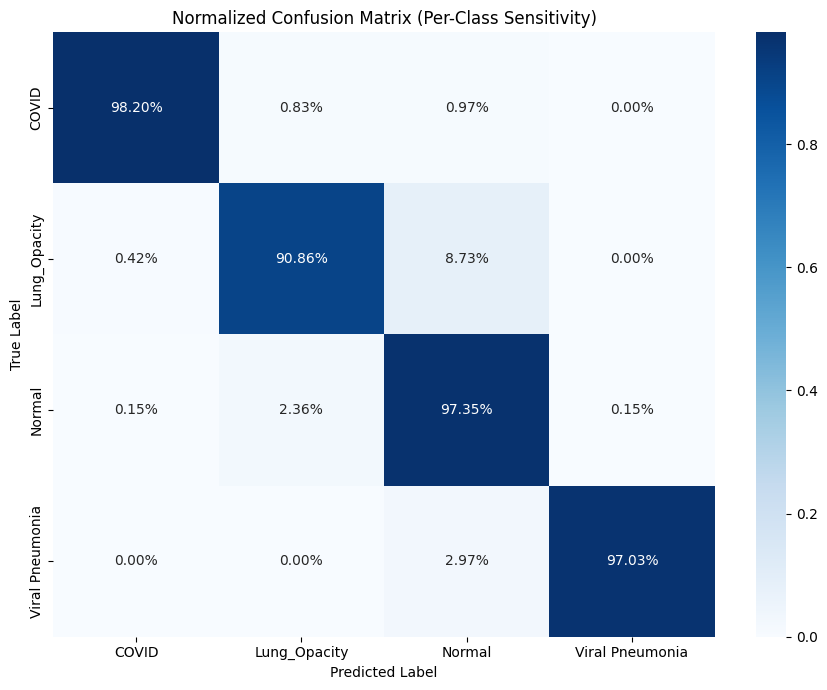

In [3]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------------------------------------------------------------
# 1. Configuration & Setup
# -------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
NUM_CLASSES = 4
CLASS_NAMES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
LABEL_MAP = {name: idx for idx, name in enumerate(CLASS_NAMES)}

# -------------------------------------------------------------
# 2. Discover Dataset & Build Test/Validation Split
# -------------------------------------------------------------
possible_roots = []
for root, dirs, _ in os.walk("/kaggle/input"):
    dir_names = set(dirs)
    if "COVID" in dir_names or "Normal" in dir_names:
        possible_roots.append(root)

BASE_PATH = possible_roots[0]

image_paths, image_labels = [], []
for root, _, files in os.walk(BASE_PATH):
    if "mask" in root.lower():
        continue
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            full_path = os.path.join(root, file)
            for cls_name, cls_idx in LABEL_MAP.items():
                if f"/{cls_name}/" in full_path.replace("\\", "/") or f"/{cls_name.replace(' ', '_')}/" in full_path.replace("\\", "/"):
                    image_paths.append(full_path)
                    image_labels.append(cls_idx)
                    break

# Same random_state to recreate the exact validation split
_, val_paths, _, val_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.20,
    random_state=42,
    stratify=image_labels
)

# -------------------------------------------------------------
# 3. DataLoader for Evaluation
# -------------------------------------------------------------
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class CXRDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

val_dataset = CXRDataset(val_paths, val_labels, transform=val_transforms)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# -------------------------------------------------------------
# 4. Load Saved Model Weights
# -------------------------------------------------------------
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

state_dict = torch.load("best_covid_resnet18.pth", map_location=DEVICE)
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()

# -------------------------------------------------------------
# 5. Run Evaluation Inference
# -------------------------------------------------------------
all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)

# -------------------------------------------------------------
# 6. Detailed Performance Breakdown
# -------------------------------------------------------------
print("=" * 65)
print("             DETAILED CLASSIFICATION REPORT")
print("=" * 65)
print(classification_report(all_targets, all_preds, target_names=CLASS_NAMES, digits=4))

# Multiclass ROC-AUC (One-vs-Rest)
y_bin = label_binarize(all_targets, classes=[0, 1, 2, 3])
macro_roc_auc = roc_auc_score(y_bin, all_probs, multi_class="ovr", average="macro")
print(f"Macro-Averaged One-vs-Rest ROC-AUC: {macro_roc_auc:.4f}")
print("=" * 65)

# -------------------------------------------------------------
# 7. Plot Confusion Matrix
# -------------------------------------------------------------
cm = confusion_matrix(all_targets, all_preds)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title("Normalized Confusion Matrix (Per-Class Sensitivity)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

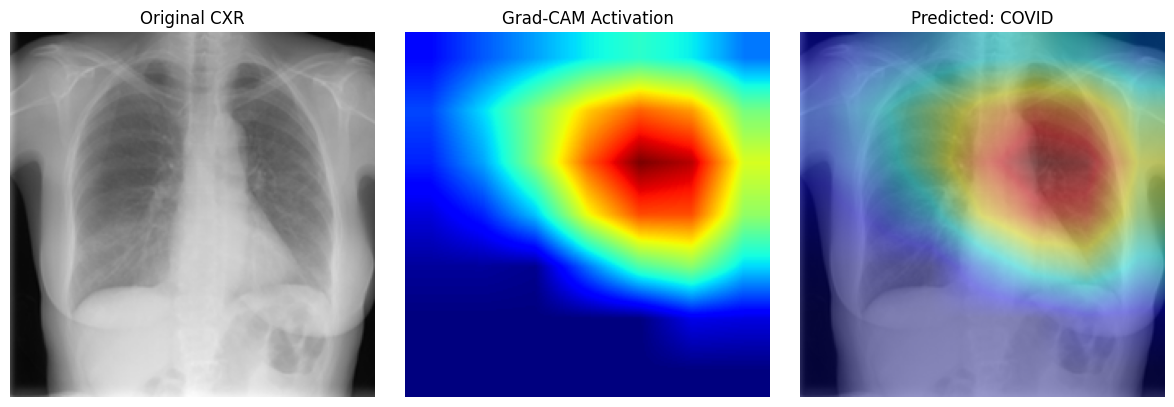

In [4]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms, models

# -------------------------------------------------------------
# 1. Setup & Model Loading
# -------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
NUM_CLASSES = 4

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
state_dict = torch.load("best_covid_resnet18.pth", map_location=DEVICE)
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()

# -------------------------------------------------------------
# 2. Grad-CAM Implementation for ResNet-18
# -------------------------------------------------------------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate_heatmap(self, input_tensor, target_class=None):
        self.model.zero_grad()
        output = self.model(input_tensor)

        if target_class is None:
            target_class = torch.argmax(output, dim=1).item()

        # Target score for backpropagation
        score = output[0, target_class]
        score.backward()

        # Global average pooling of gradients across spatial dimensions
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze().cpu().numpy()

        # Apply ReLU to keep only positive contributions
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, target_class

# -------------------------------------------------------------
# 3. Visualization Pipeline
# -------------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

grad_cam = GradCAM(model=model, target_layer=model.layer4)

def visualize_prediction(image_path):
    raw_img = Image.open(image_path).convert("RGB")
    raw_img_resized = raw_img.resize((224, 224))
    
    input_tensor = transform(raw_img).unsqueeze(0).to(DEVICE)
    
    heatmap, pred_idx = grad_cam.generate_heatmap(input_tensor)
    
    # Convert heatmap to RGB overlay
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    overlay = np.float32(heatmap_colored) / 255 * 0.4 + np.float32(raw_img_resized) / 255 * 0.6
    overlay = np.clip(overlay, 0, 1)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(raw_img_resized)
    axes[0].set_title("Original CXR")
    axes[0].axis("off")

    axes[1].imshow(heatmap, cmap="jet")
    axes[1].set_title("Grad-CAM Activation")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title(f"Predicted: {CLASS_NAMES[pred_idx]}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# Run visualization on a sample image
sample_images = glob.glob("/kaggle/input/**/COVID/images/*.png", recursive=True)
if not sample_images:
    sample_images = glob.glob("/kaggle/input/**/*.png", recursive=True)

if sample_images:
    visualize_prediction(sample_images[0])

In [5]:
import os
import glob
import time
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------------------------------------------------------------
# 1. Hardware, Hyperparameters & Directories
# -------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32          # Adjusted for 299x299 resolution
IMAGE_SIZE = 299         # Native dataset resolution
NUM_CLASSES = 4
EPOCHS = 15
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-2
LABEL_SMOOTHING = 0.1
NUM_WORKERS = 4
SAVE_DIR = "checkpoints"

os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"Available GPUs: {torch.cuda.device_count()}")

# -------------------------------------------------------------
# 2. Dynamic Dataset Discovery
# -------------------------------------------------------------
CLASS_NAMES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
LABEL_MAP = {name: idx for idx, name in enumerate(CLASS_NAMES)}

possible_roots = []
for root, dirs, _ in os.walk("/kaggle/input"):
    dir_names = set(dirs)
    if "COVID" in dir_names or "Normal" in dir_names:
        possible_roots.append(root)

if not possible_roots:
    raise FileNotFoundError(
        "Could not locate the COVID-19 dataset folders under /kaggle/input. "
        "Please ensure the dataset 'tawsifurrahman/covid19-radiography-database' is attached."
    )

BASE_PATH = possible_roots[0]
print(f"Dataset root located at: {BASE_PATH}")

image_paths, image_labels = [], []
for root, _, files in os.walk(BASE_PATH):
    if "mask" in root.lower():
        continue
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            full_path = os.path.join(root, file)
            for cls_name, cls_idx in LABEL_MAP.items():
                if f"/{cls_name}/" in full_path.replace("\\", "/") or f"/{cls_name.replace(' ', '_')}/" in full_path.replace("\\", "/"):
                    image_paths.append(full_path)
                    image_labels.append(cls_idx)
                    break

print(f"Found {len(image_paths)} total scans across {len(CLASS_NAMES)} classes.")

# -------------------------------------------------------------
# 3. Stratified Split & Balanced Loss Weights
# -------------------------------------------------------------
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.20,
    random_state=42,
    stratify=image_labels
)

# Compute inverse frequency weights for class imbalance
class_counts = [train_labels.count(i) for i in range(NUM_CLASSES)]
for cls_name, count in zip(CLASS_NAMES, class_counts):
    print(f"  - Train {cls_name}: {count} samples")

total_train_samples = sum(class_counts)
class_weights = [total_train_samples / (NUM_CLASSES * c) for c in class_counts]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f"Computed Class Weights: {class_weights_tensor.cpu().numpy().round(3)}")

# -------------------------------------------------------------
# 4. Data Pipelines & Transforms
# -------------------------------------------------------------
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class CXRDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

train_dataset = CXRDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = CXRDataset(val_paths, val_labels, transform=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# -------------------------------------------------------------
# 5. Model Architecture, Loss & Scheduler
# -------------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)

is_multi_gpu = torch.cuda.device_count() > 1
if is_multi_gpu:
    print(f"Wrapping model in DataParallel across {torch.cuda.device_count()} GPUs.")
    model = nn.DataParallel(model)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler = torch.amp.GradScaler("cuda")

# -------------------------------------------------------------
# 6. Training, Evaluation & Full Artifact Saving Loop
# -------------------------------------------------------------
best_val_macro_f1 = 0.0
best_val_acc = 0.0

print("\nStarting Training Pipeline...")
for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    
    # --- Training Phase ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS:02d} [Train]")
    for images, labels in train_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "lr": f"{optimizer.param_groups[0]['lr']:.2e}"
        })

    scheduler.step()
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = (correct_train / total_train) * 100.0

    # --- Validation Phase ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    all_val_preds = []
    all_val_targets = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            all_val_preds.extend(preds.cpu().numpy())
            all_val_targets.extend(labels.cpu().numpy())

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (correct_val / total_val) * 100.0
    epoch_macro_f1 = f1_score(all_val_targets, all_val_preds, average="macro") * 100.0
    epoch_duration = time.time() - start_time

    print(f"\n--- Epoch {epoch:02d} Results ({epoch_duration:.1f}s) ---")
    print(f"  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"  Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {epoch_val_acc:.2f}% | Macro F1: {epoch_macro_f1:.2f}%\n")

    # -------------------------------------------------------------
    # 7. Checkpoint Saving Logic
    # -------------------------------------------------------------
    # Extract raw model state if using DataParallel
    raw_model = model.module if hasattr(model, "module") else model
    raw_model_state = raw_model.state_dict()

    # Save the latest epoch state (for resuming interrupted training)
    latest_checkpoint = {
        "epoch": epoch,
        "model_state_dict": raw_model_state,
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "train_loss": epoch_train_loss,
        "val_loss": epoch_val_loss,
        "val_acc": epoch_val_acc,
        "val_macro_f1": epoch_macro_f1,
        "class_names": CLASS_NAMES,
        "label_map": LABEL_MAP
    }
    torch.save(latest_checkpoint, os.path.join(SAVE_DIR, "last_checkpoint.pth"))

    # Save best checkpoints based on Macro F1
    if epoch_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = epoch_macro_f1
        best_val_acc = epoch_val_acc

        # 1. Full Resume Checkpoint
        torch.save(latest_checkpoint, os.path.join(SAVE_DIR, "best_full_checkpoint.pth"))

        # 2. Standalone Model Weights (PyTorch State Dict only)
        torch.save(raw_model_state, os.path.join(SAVE_DIR, "best_covid_resnet18_weights.pth"))

        # 3. Local Personalized Head Only (FedRep / FedMedDx compatibility)
        head_state = {
            "weight": raw_model.fc.weight.data.clone().cpu(),
            "bias": raw_model.fc.bias.data.clone().cpu(),
            "in_features": raw_model.fc.in_features,
            "out_features": raw_model.fc.out_features,
            "class_names": CLASS_NAMES
        }
        torch.save(head_state, os.path.join(SAVE_DIR, "local_head_checkpoint.pth"))

        print(f"[*] Saved new best artifacts (Macro F1: {best_val_macro_f1:.2f}%, Accuracy: {best_val_acc:.2f}%):")
        print(f"    -> {SAVE_DIR}/best_full_checkpoint.pth (Model, Optimizer, Scheduler, Metadata)")
        print(f"    -> {SAVE_DIR}/best_covid_resnet18_weights.pth (Pure Model Weights)")
        print(f"    -> {SAVE_DIR}/local_head_checkpoint.pth (FedMedDx Local FC Head)\n")

print(f"Training Complete! Peak Macro F1: {best_val_macro_f1:.2f}% | Best Accuracy: {best_val_acc:.2f}%")

Using device: cuda
GPU Model: Tesla T4
Available GPUs: 2
Dataset root located at: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset
Found 21165 total scans across 4 classes.
  - Train COVID: 2893 samples
  - Train Lung_Opacity: 4809 samples
  - Train Normal: 8154 samples
  - Train Viral Pneumonia: 1076 samples
Computed Class Weights: [1.463 0.88  0.519 3.934]
Wrapping model in DataParallel across 2 GPUs.

Starting Training Pipeline...


Epoch 01/15 [Train]: 100%|██████████| 530/530 [01:21<00:00,  6.49it/s, loss=0.9393, lr=2.00e-04]



--- Epoch 01 Results (96.0s) ---
  Train Loss: 0.7486 | Train Acc: 86.27%
  Val   Loss: 0.6673 | Val   Acc: 91.83% | Macro F1: 91.67%

[*] Saved new best artifacts (Macro F1: 91.67%, Accuracy: 91.83%):
    -> checkpoints/best_full_checkpoint.pth (Model, Optimizer, Scheduler, Metadata)
    -> checkpoints/best_covid_resnet18_weights.pth (Pure Model Weights)
    -> checkpoints/local_head_checkpoint.pth (FedMedDx Local FC Head)



Epoch 02/15 [Train]: 100%|██████████| 530/530 [01:22<00:00,  6.45it/s, loss=1.5063, lr=1.98e-04]



--- Epoch 02 Results (96.7s) ---
  Train Loss: 0.6656 | Train Acc: 92.04%
  Val   Loss: 0.6400 | Val   Acc: 93.55% | Macro F1: 94.17%

[*] Saved new best artifacts (Macro F1: 94.17%, Accuracy: 93.55%):
    -> checkpoints/best_full_checkpoint.pth (Model, Optimizer, Scheduler, Metadata)
    -> checkpoints/best_covid_resnet18_weights.pth (Pure Model Weights)
    -> checkpoints/local_head_checkpoint.pth (FedMedDx Local FC Head)



...


--- Epoch 13 Results (97.4s) ---
  Train Loss: 0.5440 | Train Acc: 99.06%
  Val   Loss: 0.5921 | Val   Acc: 96.41% | Macro F1: 97.13%

[*] Saved new best artifacts (Macro F1: 97.13%, Accuracy: 96.41%):
    -> checkpoints/best_full_checkpoint.pth (Model, Optimizer, Scheduler, Metadata)
    -> checkpoints/best_covid_resnet18_weights.pth (Pure Model Weights)
    -> checkpoints/local_head_checkpoint.pth (FedMedDx Local FC Head)



Epoch 14/15 [Train]: 100%|██████████| 530/530 [01:22<00:00,  6.46it/s, loss=0.6375, lr=9.60e-06]



--- Epoch 14 Results (97.0s) ---
  Train Loss: 0.5421 | Train Acc: 99.19%
  Val   Loss: 0.5915 | Val   Acc: 96.29% | Macro F1: 96.73%



Epoch 15/15 [Train]: 100%|██████████| 530/530 [01:22<00:00,  6.45it/s, loss=1.6758, lr=3.17e-06]



--- Epoch 15 Results (97.1s) ---
  Train Loss: 0.5402 | Train Acc: 99.27%
  Val   Loss: 0.5926 | Val   Acc: 96.22% | Macro F1: 96.72%

Training Complete! Peak Macro F1: 97.13% | Best Accuracy: 96.41%
